# Volcano Plots
of "isolated" treatments (e.g., ambient vs. warm, normoxic vs. hypoxic)

for both phase 1 and 2 oysters, these inputs come from the respective prefilter deseq code

## 0. load libraries

In [2]:
library(tidyverse) # for ggplot and dplyr
library(cowplot) # for combining plots
library(ggrepel) # to add gene names to volcano plots

## 1. Load CSVs


From looking at differnet comparisons, the DESeq analysis resulted in 36 output files. These contain *all genes*. Here, I start by assigning directionality for genes and write CSVs that contain only DEGs.

in all of these, the LFC is in relation to the stressor against control conditions (ambient, normoxic)

#### phase 1 oysters

In [48]:
p1_DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/hypoxic_v_normoxic.csv') %>%
rename(Gene = X) %>%
mutate(signif = case_when(
    log2FoldChange >= 1 & padj <= 0.05 ~ 'hypoxic',
    log2FoldChange <= -1 & padj <= 0.05 ~ 'normoxic',
    .default = 'not significant')) %>%
mutate(phase = 'Phase 1') %>%
mutate(treatment = 'DO')

head(p1_DO)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,signif,phase,treatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC144621260,2772.7662,0.034798199,0.07967564,0.45816675,0.8826489,not significant,Phase 1,DO
2,LOC144621269,6797.3814,0.019064314,0.11424598,0.17526930,0.7241126,not significant,Phase 1,DO
3,LOC111120925,191.4430,-0.024177322,0.15098256,0.07946533,0.6178785,not significant,Phase 1,DO
4,LOC144621283,932.0540,-0.041514927,0.08482331,0.34943489,0.8318822,not significant,Phase 1,DO
5,LOC144621276,12350.8892,0.008472189,0.08487542,0.84532454,0.9737503,not significant,Phase 1,DO
6,LOC111115920,213.3386,0.079485052,0.10135715,0.02233959,0.4527059,not significant,Phase 1,DO


In [49]:
p1_temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/warm_v_ambient.csv') %>%
rename(Gene = X) %>%
mutate(signif = case_when(
    log2FoldChange >= 1 & padj <= 0.05 ~ 'warm',
    log2FoldChange <= -1 & padj <= 0.05 ~ 'ambient',
    .default = 'not significant')) %>%
mutate(phase = 'Phase 1') %>%
mutate(treatment = 'Temp')

head(p1_temp)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,signif,phase,treatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC144621260,2772.7662,-0.002891289,0.03785813,0.7754632571,0.96952461,not significant,Phase 1,Temp
2,LOC144621269,6797.3814,-0.006317804,0.09526994,0.5140319319,0.91113909,not significant,Phase 1,Temp
3,LOC111120925,191.4430,-1.183414146,1.42334409,0.0005448986,0.08387061,not significant,Phase 1,Temp
4,LOC144621283,932.0540,0.029725162,0.07638345,0.1081186420,0.65331502,not significant,Phase 1,Temp
5,LOC144621276,12350.8892,0.007028743,0.04722671,0.5516444385,0.92036871,not significant,Phase 1,Temp
6,LOC111115920,213.3386,0.023649495,0.08347554,0.1243609625,0.67637829,not significant,Phase 1,Temp


#### phase 2 oysters

In [50]:
p2_p1.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/p1_DO.csv') %>%
select(-c(7:98)) %>%
mutate(signif = case_when(
    log2FoldChange >= 1 & padj <= 0.05 ~ 'hypoxic',
    log2FoldChange <= -1 & padj <= 0.05 ~ 'normoxic',
    .default = 'not significant')) %>%
mutate(phase = 'Phase 2 Early') %>%
mutate(treatment = 'DO')

head(p2_p1.DO)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,signif,phase,treatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC144621260,1949.4353,-1.142956e-04,0.003371308,0.2165551,0.9950328,not significant,Phase 2 Early,DO
2,LOC144621269,2097.0613,-3.552269e-04,0.022059151,0.6210437,0.9997316,not significant,Phase 2 Early,DO
3,LOC111120925,132.0849,-1.742986e-04,0.021981456,0.8185242,0.9997316,not significant,Phase 2 Early,DO
4,LOC144621283,866.8099,1.699618e-05,0.002469576,0.8207352,0.9997316,not significant,Phase 2 Early,DO
5,LOC144621276,12195.3765,3.619230e-05,0.002356943,0.6698179,0.9997316,not significant,Phase 2 Early,DO
6,LOC111115920,171.8729,-4.173569e-05,0.004104199,0.6612151,0.9997316,not significant,Phase 2 Early,DO


In [51]:
p2_p1.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/p1_temp.csv') %>%
select(-c(7:98)) %>%
mutate(signif = case_when(
    log2FoldChange >= 1 & padj <= 0.05 ~ 'warm',
    log2FoldChange <= -1 & padj <= 0.05 ~ 'ambient',
    .default = 'not significant')) %>%
mutate(phase = 'Phase 2 Early') %>%
mutate(treatment = 'Temp')

In [52]:
p2_p2.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/p2_DO.csv') %>%
select(-c(7:98)) %>%
mutate(signif = case_when(
    log2FoldChange >= 1 & padj <= 0.05 ~ 'hypoxic',
    log2FoldChange <= -1 & padj <= 0.05 ~ 'normoxic',
    .default = 'not significant')) %>%
mutate(phase = 'Phase 2 Late') %>%
mutate(treatment = 'DO')

In [53]:
p2_p2.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/p2_temp.csv') %>%
select(-c(7:98)) %>%
mutate(signif = case_when(
    log2FoldChange >= 1 & padj <= 0.05 ~ 'warm',
    log2FoldChange <= -1 & padj <= 0.05 ~ 'ambient',
    .default = 'not significant')) %>%
mutate(phase = 'Phase 2 Late') %>%
mutate(treatment = 'Temp')

In [54]:
all.df <- rbind(p1_temp, p1_DO, p2_p1.temp, p2_p1.DO, p2_p2.temp, p2_p2.DO)

dim(all.df)
head(all.df)
tail(all.df)

[1] 154632      9

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,signif,phase,treatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC144621260,2772.7662,-0.002891289,0.03785813,0.7754632571,0.96952461,not significant,Phase 1,Temp
2,LOC144621269,6797.3814,-0.006317804,0.09526994,0.5140319319,0.91113909,not significant,Phase 1,Temp
3,LOC111120925,191.4430,-1.183414146,1.42334409,0.0005448986,0.08387061,not significant,Phase 1,Temp
4,LOC144621283,932.0540,0.029725162,0.07638345,0.1081186420,0.65331502,not significant,Phase 1,Temp
5,LOC144621276,12350.8892,0.007028743,0.04722671,0.5516444385,0.92036871,not significant,Phase 1,Temp
6,LOC111115920,213.3386,0.023649495,0.08347554,0.1243609625,0.67637829,not significant,Phase 1,Temp


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,signif,phase,treatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
154627,LOC111111213,10681.990710,0.0622962696,0.05166686,0.095182095,0.4450656,not significant,Phase 2 Late,DO
154628,LOC111114497,176.726897,0.0080568548,0.06999183,0.820377158,0.9573528,not significant,Phase 2 Late,DO
154629,LOC111114498,2762.057757,0.1153612089,0.05913503,0.005649625,0.1078944,not significant,Phase 2 Late,DO
154630,LOC111112304,1105.483751,0.0341229229,0.04997288,0.345320288,0.7415164,not significant,Phase 2 Late,DO
154631,LOC144621306,9.832551,-0.0002720008,0.10163564,0.988078897,0.9973437,not significant,Phase 2 Late,DO
154632,LOC144621888,32.317563,0.0194508086,0.09975340,0.403703630,0.7787789,not significant,Phase 2 Late,DO


## 2. using `ggplot` to make volcano plots

Warning message:
“Removed 3471 rows containing missing values or values outside the scale range
(`geom_point()`).”


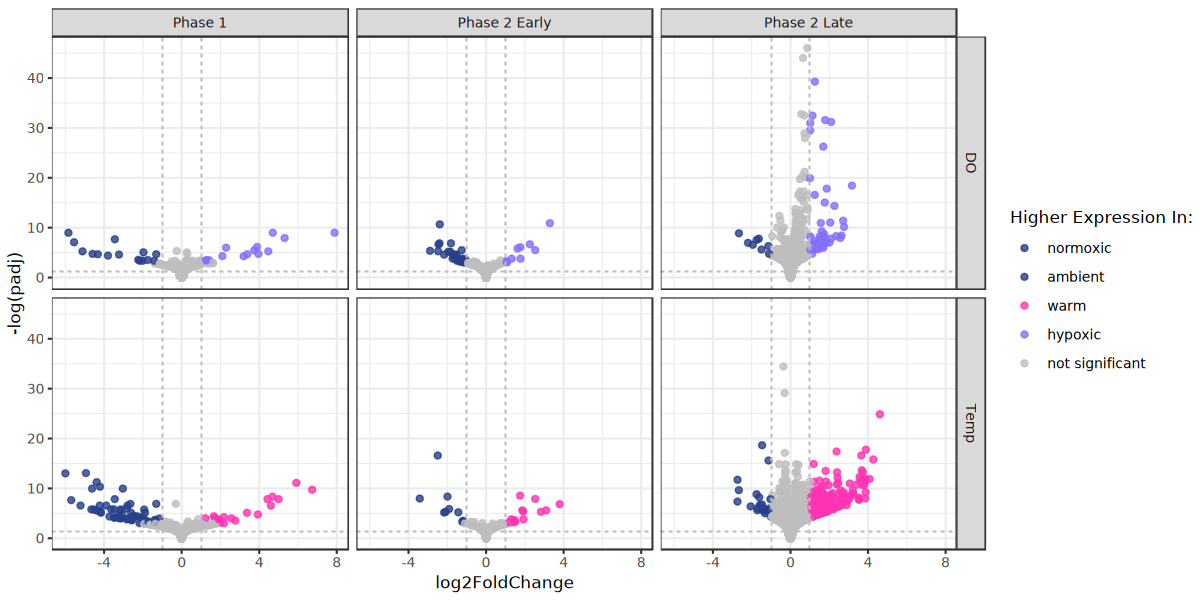

In [60]:
options(repr.plot.width = 10, repr.plot.height = 5)

# change order of legend
all.df$signif <- factor(all.df$signif, levels = c('normoxic','ambient','warm','hypoxic','not significant'))

ggplot(all.df, aes(x = log2FoldChange, y = -log(padj), color = signif)) +
geom_point(alpha = 0.8) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
facet_grid(treatment ~ phase) +
scale_color_manual(values = c('not significant' = 'grey', 
                              'warm' = 'maroon1', 
                              'hypoxic' = 'slateblue1', 
                              'ambient' = 'royalblue4', 
                              'normoxic' = 'royalblue4')) +
labs(color = 'Higher Expression In:'
    ) +
theme_bw(base_size = 10)